<a href="https://colab.research.google.com/github/lazic7/MSAP/blob/master/LV2_ponavljanje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import chi2_contingency
import numpy as np
import scipy.stats as st
import scipy.stats as stats

In [ ]:
df = pd.read_csv("hormon.csv", sep=";", decimal=",").convert_dtypes()
df.columns = df.columns.str.strip(",")
df.columns

Index(['spol', 'gastrS', 'somatS', 'somatZ', 'pusenje', 'alkohol', 'kava',
       'CLOtest', 'dijagnoza'],
      dtype='object')

In [ ]:
df['dijagnoza'] = (
    df['dijagnoza']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['dijagnoza'].unique()

array(['G', 'E b', 'U b', 'U z', 'E z'], dtype=object)

In [ ]:
df.head()

,spol,gastrS,somatS,somatZ,pusenje,alkohol,kava,CLOtest,dijagnoza
0,z,92.3,3.1,29.31,1,0,1,1,G
1,z,49.5,8.5,5.52,0,0,1,1,G
2,z,40.5,16.2,15.22,1,0,1,0,G
3,z,42.7,16.0,3.67,0,0,1,0,G
4,z,48.2,16.0,66.97,1,0,1,0,G


In [ ]:
df.tail()

,spol,gastrS,somatS,somatZ,pusenje,alkohol,kava,CLOtest,dijagnoza
77,m,53.3,2.34,140.21,0,1,1,1,E z
78,z,49.8,8.68,112.35,1,0,1,1,U b
79,m,50.9,15.88,125.34,0,1,1,0,E b
80,z,59.3,12.63,20.13,0,0,0,1,U b
81,z,45.3,73.51,17.65,0,0,1,0,U b


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   spol       82 non-null     string 
 1   gastrS     78 non-null     Float64
 2   somatS     77 non-null     Float64
 3   somatZ     81 non-null     Float64
 4   pusenje    82 non-null     Int64  
 5   alkohol    82 non-null     Int64  
 6   kava       82 non-null     Int64  
 7   CLOtest    82 non-null     Int64  
 8   dijagnoza  82 non-null     object 
dtypes: Float64(3), Int64(4), object(1), string(1)
memory usage: 6.5+ KB


Podaci su učitani iz CSV datoteke s prilagođenim separatorom i decimalnim zapisom. Uočen je problem s dodatnim separatorima u zaglavlju i vrijednostima kategorijskih varijabli, koji je riješen čišćenjem naziva stupaca i standardizacijom vrijednosti. Nakon toga provjerene su nedostajuće vrijednosti i duplikati. Dataset je spreman za daljnju analizu.

In [ ]:
df.isnull().sum()

,0
spol,0
gastrS,4
somatS,5
somatZ,1
pusenje,0
alkohol,0
kava,0
CLOtest,0
dijagnoza,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['gastrS'] = df['gastrS'].fillna(df['gastrS'].median())
df['somatS'] = df['somatS'].fillna(df['somatS'].median())
df['somatZ'] = df['somatZ'].fillna(df['somatZ'].median())
df.isnull().sum()

,0
spol,0
gastrS,0
somatS,0
somatZ,0
pusenje,0
alkohol,0
kava,0
CLOtest,0
dijagnoza,0


In [ ]:
df.shape

(82, 9)

In [ ]:
df['somatS'].describe()

,somatS
count,82.0
mean,20.527073
std,31.833874
min,2.34
25%,6.84
50%,11.05
75%,16.175
max,231.0


In [ ]:
variables = ['somatS']

desc_stats = pd.DataFrame({
    'Sredina': df[variables].mean(),
    'Median': df[variables].median(),
    'Mod': df[variables].mode().iloc[0],
    'Std. Dev.': df[variables].std(),
    'Raspon': df[variables].max() - df[variables].min(),
    'Skewness': df[variables].skew(),
    'Kurtosis': df[variables].kurtosis()
})

desc_stats

,Sredina,Median,Mod,Std. Dev.,Raspon,Skewness,Kurtosis
somatS,20.527073,11.05,11.05,31.833874,228.66,4.516282,25.040394


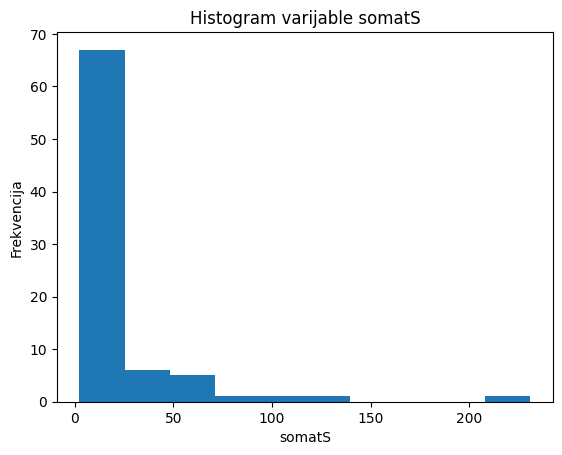

In [ ]:
plt.hist(df['somatS'])
plt.xlabel('somatS')
plt.ylabel('Frekvencija')
plt.title('Histogram varijable somatS')
plt.show()

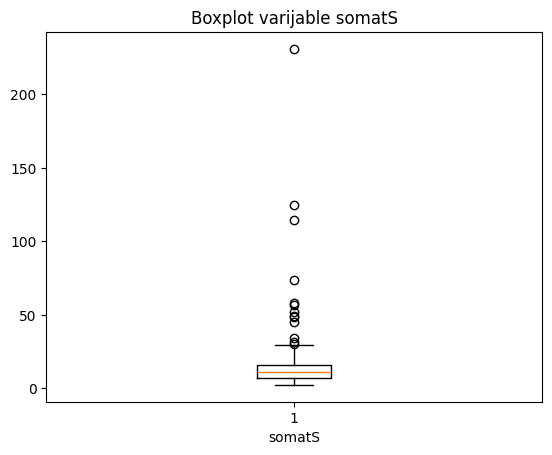

In [ ]:
plt.boxplot(df['somatS'])
plt.xlabel('somatS')
plt.title('Boxplot varijable somatS')
plt.show()

Varijabla somatS ima srednju vrijednost 20.527 i medijan 11.05. Vrijednosti su (relativno) asimetrično raspoređene, što je vidljivo iz histograma i vrijednosti koeficijenta asimetrije skewness > 0, dakle desno nagnuta odnosno pozitivna asimetrija. Boxplot pokazuje postojanje ekstremnih vrijednosti.

In [ ]:
stat, p_value = shapiro(df['somatS'])

print(f"Shapiro–Wilk statistika: {stat}")
print(f"p-vrijednost: {p_value}")

Shapiro–Wilk statistika: 0.49047063509188693
p-vrijednost: 2.186005764291415e-15


H₀: somatS je normalno distribuiran

H₁: somatS nije normalno distribuiran

p < 0.05 → odbacujemo H₀ → distribucija nije normalna

In [ ]:
# Podatci o uzorku
n = df.shape[0] # Veličina uzorka (n je 82)
srednja_vrijednost = df['somatS'].mean() # Srednja vrijednost uzorka
# ddpf=1 Zato što se radi o uzorku, a ne populaciji,
# te se primjenjuje Besselova korekcija kako bi se dobila nepristrana procjena
standardna_devijacija = df['somatS'].std(ddof=1) # Procjena standardne devijacije uzorka (uzorak veci od 30)

# Razina pouzdanosti
razina_pouzdanosti = 0.95
alfa = 1 - razina_pouzdanosti
#nije poznata varijanca populacije, racuna se kriticna vrijednost t-distribucije t*
t_vrijednost = stats.t.ppf(1 - alfa / 2, df=n-1)

# Izračun margine pogreške
margina_pogreske = t_vrijednost * (standardna_devijacija / np.sqrt(n-1))

# Interval povjerenja
donja_granica = srednja_vrijednost - margina_pogreske
gornja_granica = srednja_vrijednost + margina_pogreske
print(f"95% interval povjerenja: ({donja_granica:.2f},{gornja_granica:.2f})")

95% interval povjerenja: (13.49,27.56)


S 95% pouzdanosti možemo tvrditi da se stvarna srednja vrijednost razine hormona somatS u populaciji nalazi unutar dobivenog intervala povjerenja (13.49, 27.56).

In [ ]:
cont_table = pd.crosstab(df['spol'], df['pusenje'])
chi2, p, dof, expected = chi2_contingency(cont_table)

print(f"Chi-square statistika: {chi2}")
print(f"p-vrijednost: {p}")

Chi-square statistika: 3.9201585881818457
p-vrijednost: 0.047710379340530996


H₀: spol i pušenje su neovisni

H₁: postoji povezanost

p < 0.05 - odbacuje se H₀ → postoji statistički značajna povezanost

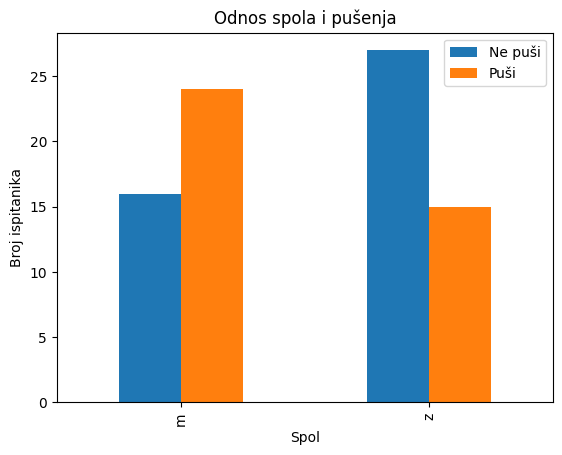

In [ ]:
cont_table.plot(kind='bar')
plt.title('Odnos spola i pušenja')
plt.xlabel('Spol')
plt.ylabel('Broj ispitanika')
plt.legend(['Ne puši', 'Puši'])
plt.show()

✅ ZAKLJUČNA ANALIZA – ODGOVORI NA PITANJA

1️⃣ Kako ste provjerili normalnost podataka i što ste zaključili?

Normalnost distribucije varijable somatS provjerena je Shapiro–Wilk testom.

Nulta hipoteza (H₀): podaci su normalno distribuirani

Alternativna hipoteza (H₁): podaci nisu normalno distribuirani

Dobivena p-vrijednost = 2.19 × 10⁻¹⁵, što je značajno manje od razine značajnosti α = 0.05.
Stoga se odbacuje nulta hipoteza, te se zaključuje da distribucija varijable somatS nije normalna.

Ovaj zaključak je u skladu i s eksplorativnom analizom, koja je pokazala desnu asimetriju distribucije i prisutnost ekstremnih vrijednosti.

2️⃣ Koji ste test koristili za usporedbu skupina (t-test ili Mann–Whitney U test) i zašto?

U ovom zadatku nije provedena usporedba srednjih vrijednosti između dviju numeričkih skupina, već:

intervalna procjena srednje vrijednosti jedne varijable (somatS)

ispitivanje povezanosti dviju kategorijskih varijabli (spol i pušenje)

Za procjenu srednje vrijednosti varijable somatS korištena je t-distribucija pri izračunu intervala povjerenja, unatoč nenormalnosti distribucije, jer:

standardna devijacija populacije nije poznata

veličina uzorka je relativno velika (n = 82)

t-interval povjerenja je robustan na odstupanja od normalnosti

Za ispitivanje povezanosti između spola i pušenja korišten je Chi-square test neovisnosti, jer se radi o dvjema kategorijskim varijablama.

3️⃣ Koji je iznos 95% intervala povjerenja za razinu hormona somatostatina i kako ga tumačite?

Dobiveni 95% interval povjerenja za srednju vrijednost razine hormona somatostatina u serumu (somatS) iznosi:

(13.49,  27.56)
(13.49,27.56)

Tumačenje:

S 95% pouzdanosti možemo tvrditi da se stvarna srednja vrijednost razine hormona somatostatina u populaciji nalazi unutar navedenog intervala.

Važno je naglasiti da interval povjerenja ne znači da je vjerojatnost 95% da se srednja vrijednost nalazi u tom intervalu, već da bi u 95% slučajeva intervali izračunati na temelju uzoraka sadržavali pravu populacijsku sredinu.

4️⃣ Postoji li značajna razlika između muškaraca i žena u navikama pušenja?

Povezanost između varijabli spol i pušenje ispitana je pomoću Chi-square testa neovisnosti.

Dobivena p-vrijednost: p = 0.0477

Razina značajnosti: α = 0.05

Budući da je p-vrijednost manja od razine značajnosti, odbacuje se nulta hipoteza o neovisnosti, te se zaključuje da postoji statistički značajna povezanost između spola i pušenja u promatranom uzorku.

5️⃣ Koji bi mogli biti mogući razlozi za uočene razlike (ili njihov izostanak)?

Mogući razlozi za uočenu statistički značajnu povezanost između spola i pušenja uključuju:

razlike u životnim navikama i ponašanju između muškaraca i žena

sociokulturne čimbenike

različitu zastupljenost pušača po spolu u uzorku

S obzirom da se radi o opservacijskim podacima, nije moguće zaključiti uzročno-posljedičnu vezu, već samo postojanje statističke povezanosti.